# 📚 Case Study 3: Büyük Ölçekli N-gram Dil Modeli

Bu case study'de **N-gram modelleri** kullanarak büyük ölçekli bir dil modeli geliştirip metin üretimi yapacağız.

## 🎯 Proje Hedefleri

- Reuters corpus ile 100,000+ kelime içeren dil modeli
- 2-gram, 3-gram, 4-gram ve 5-gram modellerini karşılaştırma
- Smoothing teknikleri uygulama
- Perplexity ile model kalitesini değerlendirme
- Otomatik metin üretimi sistemi

## 📋 İçerik

1. [Büyük Corpus Hazırlığı](#corpus-hazirligi)
2. [N-gram Model Geliştirme](#ngram-model)
3. [Smoothing Teknikleri](#smoothing)
4. [Model Karşılaştırması](#model-karsilastirma)
5. [Metin Üretimi](#metin-uretimi)
6. [Kalite Değerlendirme](#kalite-degerlendirme)

---

**Teknikler:** Add-one Smoothing, Good-Turing Smoothing, Perplexity Calculation

In [1]:
# 🔧 ADIM 1: Gerekli Kütüphaneleri İçe Aktarma
# N-gram dil modeli geliştirmek için gerekli tüm kütüphaneleri yüklüyoruz

import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from nltk.corpus import reuters, brown
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.util import ngrams
import re
import warnings
warnings.filterwarnings('ignore')

# Türkçe karakter desteği için
plt.rcParams['font.family'] = ['DejaVu Sans']

# NLTK veri setlerini indirme
try:
    nltk.data.find('corpora/reuters')
    nltk.data.find('corpora/brown')
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("📥 Gerekli NLTK veri setleri indiriliyor...")
    nltk.download('reuters')
    nltk.download('brown')
    nltk.download('punkt')
    print("✅ İndirme işlemi tamamlandı!")

print("🚀 Kütüphaneler başarıyla yüklendi!")

📥 Gerekli NLTK veri setleri indiriliyor...
✅ İndirme işlemi tamamlandı!
🚀 Kütüphaneler başarıyla yüklendi!
✅ İndirme işlemi tamamlandı!
🚀 Kütüphaneler başarıyla yüklendi!


[nltk_data] Downloading package reuters to
[nltk_data]     C:\Users\Cemal\AppData\Roaming\nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\Cemal\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Cemal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# 📊 ADIM 2: Büyük Corpus Veri Setini Hazırlama
# Reuters ve Brown corpuslarından büyük bir metin veri seti oluşturuyoruz

class CorpusPreprocessor:
    """
    Büyük corpus verilerini işlemek için sınıf
    - Metinleri temizleme
    - Tokenization
    - Normalizasyon işlemleri
    """
    
    def __init__(self):
        self.processed_sentences = []
        self.vocab = set()
        self.word_counts = Counter()
    
    def clean_text(self, text):
        """Metni temizleme ve normalizasyon"""
        # Küçük harfe çevirme
        text = text.lower()
        
        # Özel karakterleri temizleme (sadece harf, rakam ve noktalama)
        text = re.sub(r'[^\w\s\.,!?;:]', '', text)
        
        # Çoklu boşlukları tek boşluğa çevirme
        text = re.sub(r'\s+', ' ', text)
        
        return text.strip()
    
    def tokenize_sentences(self, text):
        """Metni cümlelere ve kelimelere ayırma"""
        sentences = sent_tokenize(text)
        tokenized_sentences = []
        
        for sentence in sentences:
            # Cümleyi temizle
            clean_sentence = self.clean_text(sentence)
            
            # Kelimelere ayır
            words = word_tokenize(clean_sentence)
            
            # En az 3 kelimeli cümleleri al
            if len(words) >= 3:
                # Başlangıç ve bitiş tokenları ekle
                sentence_with_markers = ['<START>'] + words + ['<END>']
                tokenized_sentences.append(sentence_with_markers)
                
                # Kelime sayılarını güncelle
                for word in sentence_with_markers:
                    self.word_counts[word] += 1
                    self.vocab.add(word)
        
        return tokenized_sentences
    
    def process_corpus(self, max_sentences=10000):
        """Corpus'u işleme ve hazırlama"""
        print("📚 Corpus verileri yükleniyor...")
        
        # Reuters corpus'undan metinler
        reuters_sentences = []
        reuters_fileids = reuters.fileids()[:500]  # İlk 500 dosya
        
        for fileid in reuters_fileids[:100]:  # Performans için sınırlı
            try:
                text = reuters.raw(fileid)
                sentences = self.tokenize_sentences(text)
                reuters_sentences.extend(sentences)
                
                if len(reuters_sentences) >= max_sentences // 2:
                    break
            except Exception as e:
                continue
        
        # Brown corpus'undan metinler
        brown_sentences = []
        brown_fileids = brown.fileids()[:200]  # İlk 200 dosya
        
        for fileid in brown_fileids:
            try:
                text = brown.raw(fileid)
                sentences = self.tokenize_sentences(text)
                brown_sentences.extend(sentences)
                
                if len(brown_sentences) >= max_sentences // 2:
                    break
            except Exception as e:
                continue
        
        # Tüm cümleleri birleştir
        self.processed_sentences = reuters_sentences + brown_sentences
        
        print(f"✅ Toplam {len(self.processed_sentences)} cümle işlendi")
        print(f"📖 Vocabulary boyutu: {len(self.vocab)}")
        print(f"🔢 Toplam kelime sayısı: {sum(self.word_counts.values())}")
        
        return self.processed_sentences

# Corpus preprocessor'ı oluştur ve çalıştır
preprocessor = CorpusPreprocessor()
sentences = preprocessor.process_corpus(max_sentences=5000)

# İlk birkaç örnek cümleyi göster
print("\n📝 Örnek işlenmiş cümler:")
for i, sentence in enumerate(sentences[:3]):
    print(f"{i+1}. {' '.join(sentence[:10])}...")

print(f"\n📊 İstatistikler:")
print(f"- Toplam cümle sayısı: {len(sentences)}")
print(f"- Vocabulary boyutu: {len(preprocessor.vocab)}")
print(f"- En sık kullanılan 10 kelime:")
for word, count in preprocessor.word_counts.most_common(10):
    print(f"  {word}: {count}")

📚 Corpus verileri yükleniyor...
✅ Toplam 3200 cümle işlendi
📖 Vocabulary boyutu: 14630
🔢 Toplam kelime sayısı: 87179

📝 Örnek işlenmiş cümler:
1. <START> asian exporters fear damage from u.s.japan rift mounting trade...
2. <START> they told reuter correspondents in asian capitals a u.s....
3. <START> but some exporters said that while the conflict would...

📊 İstatistikler:
- Toplam cümle sayısı: 3200
- Vocabulary boyutu: 14630
- En sık kullanılan 10 kelime:
  ,: 6958
  theat: 3855
  <START>: 3200
  <END>: 3200
  ..: 2474
  ofin: 1674
  aat: 1305
  andcc: 1272
  inin: 1184
  the: 832
✅ Toplam 3200 cümle işlendi
📖 Vocabulary boyutu: 14630
🔢 Toplam kelime sayısı: 87179

📝 Örnek işlenmiş cümler:
1. <START> asian exporters fear damage from u.s.japan rift mounting trade...
2. <START> they told reuter correspondents in asian capitals a u.s....
3. <START> but some exporters said that while the conflict would...

📊 İstatistikler:
- Toplam cümle sayısı: 3200
- Vocabulary boyutu: 14630
- En sık 

In [3]:
# 🧮 ADIM 3: N-gram Dil Modeli Sınıfını Oluşturma
# Farklı N değerleri için esnek N-gram modeli sınıfı

class NgramLanguageModel:
    """
    N-gram tabanlı dil modeli sınıfı
    - Farklı N değerleri destekler (unigram, bigram, trigram, vb.)
    - Add-one (Laplace) smoothing uygular
    - Perplexity hesaplar
    - Metin üretimi yapar
    """
    
    def __init__(self, n=2):
        self.n = n  # N-gram boyutu
        self.ngram_counts = defaultdict(int)  # N-gram sayıları
        self.context_counts = defaultdict(int)  # Bağlam sayıları (n-1)-gram
        self.vocabulary = set()  # Vocabulary
        self.vocab_size = 0
        
    def train(self, sentences):
        """Modeli eğitme"""
        print(f"🎯 {self.n}-gram modeli eğitiliyor...")
        
        # Vocabulary oluştur
        for sentence in sentences:
            for word in sentence:
                self.vocabulary.add(word)
        
        self.vocab_size = len(self.vocabulary)
        print(f"📖 Vocabulary boyutu: {self.vocab_size}")
        
        # N-gram'ları oluştur ve say
        total_ngrams = 0
        for sentence in sentences:
            # N-gram'ları oluştur
            sentence_ngrams = list(ngrams(sentence, self.n))
            
            for ngram in sentence_ngrams:
                # N-gram sayısını artır
                self.ngram_counts[ngram] += 1
                
                # Bağlam (n-1)-gram sayısını artır
                if self.n > 1:
                    context = ngram[:-1]
                    self.context_counts[context] += 1
                
                total_ngrams += 1
        
        print(f"🔢 Toplam {total_ngrams} adet {self.n}-gram oluşturuldu")
        print(f"📊 Unique {self.n}-gram sayısı: {len(self.ngram_counts)}")
        
        # En sık kullanılan N-gram'ları göster
        print(f"\n🏆 En sık kullanılan {self.n}-gram'lar:")
        for ngram, count in sorted(self.ngram_counts.items(), 
                                 key=lambda x: x[1], reverse=True)[:5]:
            print(f"  {' '.join(ngram)}: {count}")
    
    def get_probability(self, ngram, smoothing=True):
        """
        N-gram olasılığını hesaplama
        Add-one (Laplace) smoothing ile
        """
        if self.n == 1:
            # Unigram için
            total_words = sum(self.ngram_counts.values())
            if smoothing:
                # Add-one smoothing
                return (self.ngram_counts[ngram] + 1) / (total_words + self.vocab_size)
            else:
                return self.ngram_counts[ngram] / total_words if total_words > 0 else 0
        else:
            # N-gram için (n > 1)
            context = ngram[:-1]
            context_count = self.context_counts[context]
            
            if smoothing:
                # Add-one smoothing
                return (self.ngram_counts[ngram] + 1) / (context_count + self.vocab_size)
            else:
                return self.ngram_counts[ngram] / context_count if context_count > 0 else 0
    
    def calculate_perplexity(self, test_sentences):
        """Model kalitesini ölçmek için perplexity hesaplama"""
        print(f"🧪 {self.n}-gram modeli için perplexity hesaplanıyor...")
        
        total_log_prob = 0
        total_words = 0
        
        for sentence in test_sentences:
            sentence_ngrams = list(ngrams(sentence, self.n))
            
            for ngram in sentence_ngrams:
                prob = self.get_probability(ngram, smoothing=True)
                
                if prob > 0:
                    total_log_prob += np.log2(prob)
                else:
                    # Çok küçük olasılık için
                    total_log_prob += np.log2(1e-10)
                
                total_words += 1
        
        if total_words == 0:
            return float('inf')
        
        # Perplexity = 2^(-log_prob / N)
        avg_log_prob = total_log_prob / total_words
        perplexity = 2 ** (-avg_log_prob)
        
        print(f"📈 {self.n}-gram Perplexity: {perplexity:.2f}")
        return perplexity
    
    def generate_text(self, start_context=None, max_length=20):
        """N-gram modeli kullanarak metin üretme"""
        if self.n == 1:
            # Unigram için basit random seçim
            words = []
            for _ in range(max_length):
                # Olasılıklara göre kelime seç
                word_probs = []
                for word in self.vocabulary:
                    if word not in ['<START>', '<END>']:
                        prob = self.get_probability((word,))
                        word_probs.append((word, prob))
                
                if word_probs:
                    # En olası kelimeleri seç
                    word_probs.sort(key=lambda x: x[1], reverse=True)
                    selected_word = np.random.choice(
                        [w for w, p in word_probs[:50]], 
                        p=[p for w, p in word_probs[:50]] / 
                          np.sum([p for w, p in word_probs[:50]])
                    )
                    
                    if selected_word == '<END>':
                        break
                    words.append(selected_word)
            
            return ' '.join(words)
        
        else:
            # N-gram için (n > 1)
            if start_context is None:
                # Rastgele başlangıç bağlamı seç
                contexts = list(self.context_counts.keys())
                start_context = contexts[np.random.randint(len(contexts))]
            
            generated = list(start_context)
            
            for _ in range(max_length):
                # Mevcut bağlam
                current_context = tuple(generated[-(self.n-1):])
                
                # Bu bağlamla başlayan tüm N-gram'ları bul
                candidates = []
                for ngram, count in self.ngram_counts.items():
                    if ngram[:-1] == current_context:
                        prob = self.get_probability(ngram)
                        candidates.append((ngram[-1], prob))
                
                if not candidates:
                    break
                
                # Olasılıklara göre kelime seç
                candidates.sort(key=lambda x: x[1], reverse=True)
                
                # En olası 10 kelime arasından seç
                top_candidates = candidates[:10]
                words, probs = zip(*top_candidates)
                probs = np.array(probs)
                probs = probs / probs.sum()  # Normalize et
                
                next_word = np.random.choice(words, p=probs)
                
                if next_word == '<END>':
                    break
                
                generated.append(next_word)
            
            # START tokenını kaldır
            if generated and generated[0] == '<START>':
                generated = generated[1:]
            
            return ' '.join(generated)

# Test için farklı N değerleri için modeller oluştur
print("🏗️ Farklı N-gram modelleri oluşturuluyor...")
models = {}

for n in [2, 3, 4]:  # Bigram, Trigram, 4-gram
    print(f"\n{'='*50}")
    print(f"🔨 {n}-gram Modeli Oluşturuluyor")
    print(f"{'='*50}")
    
    model = NgramLanguageModel(n=n)
    model.train(sentences)
    models[n] = model

print("\n✅ Tüm N-gram modelleri başarıyla oluşturuldu!")

🏗️ Farklı N-gram modelleri oluşturuluyor...

🔨 2-gram Modeli Oluşturuluyor
🎯 2-gram modeli eğitiliyor...
📖 Vocabulary boyutu: 14630
🔢 Toplam 83979 adet 2-gram oluşturuldu
📊 Unique 2-gram sayısı: 51615

🏆 En sık kullanılan 2-gram'lar:
  , ,: 3139
  .. <END>: 2467
  . <END>: 712
  ofin theat: 514
  <START> theat: 443

🔨 3-gram Modeli Oluşturuluyor
🎯 3-gram modeli eğitiliyor...
📖 Vocabulary boyutu: 14630
🔢 Toplam 80779 adet 3-gram oluşturuldu
📊 Unique 3-gram sayısı: 70257

🏆 En sık kullanılan 3-gram'lar:
  , , andcc: 217
  , , theat: 204
  said . <END>: 110
  , , whowps: 90
  , , hepps: 85

🔨 4-gram Modeli Oluşturuluyor
🎯 4-gram modeli eğitiliyor...
📖 Vocabulary boyutu: 14630
🔢 Toplam 77579 adet 4-gram oluşturuldu
📊 Unique 4-gram sayısı: 74379

🏆 En sık kullanılan 4-gram'lar:
  , , hepps saidvbd: 47
  , he said .: 25
  he said . <END>: 25
  hepps saidvbd , ,: 25
  , hepps saidvbd ,: 23

✅ Tüm N-gram modelleri başarıyla oluşturuldu!


In [4]:
# 🔬 ADIM 4: Smoothing Teknikleri ve Model Karşılaştırması
# Farklı smoothing tekniklerini uygulayıp model performanslarını karşılaştırıyoruz

class AdvancedNgramModel(NgramLanguageModel):
    """
    Gelişmiş N-gram modeli
    - Good-Turing smoothing
    - Interpolation
    - Back-off stratejisi
    """
    
    def __init__(self, n=2):
        super().__init__(n)
        self.good_turing_counts = {}
        self.discounting_factor = 0.75
    
    def calculate_good_turing_smoothing(self):
        """Good-Turing smoothing hesaplama"""
        print("🔧 Good-Turing smoothing hesaplanıyor...")
        
        # N-gram frekans dağılımını hesapla
        frequency_of_frequencies = defaultdict(int)
        
        for count in self.ngram_counts.values():
            frequency_of_frequencies[count] += 1
        
        # Good-Turing formülü uygula
        self.good_turing_counts = {}
        
        for ngram, count in self.ngram_counts.items():
            if count < 5:  # Düşük frekanslı N-gram'lar için
                if count + 1 in frequency_of_frequencies:
                    adjusted_count = (count + 1) * frequency_of_frequencies[count + 1] / frequency_of_frequencies[count]
                    self.good_turing_counts[ngram] = adjusted_count
                else:
                    self.good_turing_counts[ngram] = count
            else:
                self.good_turing_counts[ngram] = count
    
    def get_probability_with_smoothing(self, ngram, method='add_one'):
        """Farklı smoothing teknikleri ile olasılık hesaplama"""
        
        if method == 'add_one':
            return self.get_probability(ngram, smoothing=True)
        
        elif method == 'good_turing':
            if not self.good_turing_counts:
                self.calculate_good_turing_smoothing()
            
            if self.n == 1:
                total_words = sum(self.good_turing_counts.values())
                return self.good_turing_counts.get(ngram, 0.1) / total_words
            else:
                context = ngram[:-1]
                context_count = self.context_counts[context]
                return self.good_turing_counts.get(ngram, 0.1) / context_count if context_count > 0 else 0.0001
        
        elif method == 'interpolation':
            # Linear interpolation (sadece trigram için)
            if self.n != 3:
                return self.get_probability(ngram, smoothing=True)
            
            # Trigram, bigram, unigram olasılıklarını birleştir
            lambda1, lambda2, lambda3 = 0.6, 0.3, 0.1
            
            # Trigram olasılığı
            trigram_prob = self.get_probability(ngram, smoothing=True)
            
            # Bigram olasılığı (son 2 kelime)
            bigram = ngram[-2:]
            bigram_count = sum(1 for ng in self.ngram_counts.keys() if ng[-2:] == bigram)
            bigram_prob = bigram_count / len(self.ngram_counts) if len(self.ngram_counts) > 0 else 0
            
            # Unigram olasılığı (son kelime)
            unigram = ngram[-1:]
            unigram_count = sum(1 for ng in self.ngram_counts.keys() if ng[-1:] == unigram)
            unigram_prob = unigram_count / len(self.ngram_counts) if len(self.ngram_counts) > 0 else 0
            
            return lambda1 * trigram_prob + lambda2 * bigram_prob + lambda3 * unigram_prob
        
        else:
            return self.get_probability(ngram, smoothing=True)

# Test veri seti hazırla (son %20'si test için)
test_size = len(sentences) // 5
train_sentences = sentences[:-test_size]
test_sentences = sentences[-test_size:]

print(f"📊 Veri seti bölünmesi:")
print(f"- Eğitim: {len(train_sentences)} cümle")
print(f"- Test: {len(test_sentences)} cümle")

# Gelişmiş modeller oluştur ve karşılaştır
print("\n🚀 Gelişmiş modeller oluşturuluyor...")

advanced_models = {}
smoothing_methods = ['add_one', 'good_turing', 'interpolation']

for n in [2, 3]:  # Bigram ve Trigram için
    print(f"\n{'='*60}")
    print(f"📈 {n}-gram Modeli için Smoothing Karşılaştırması")
    print(f"{'='*60}")
    
    model = AdvancedNgramModel(n=n)
    model.train(train_sentences)
    
    # Farklı smoothing teknikleri için perplexity hesapla
    results = {}
    
    for method in smoothing_methods:
        if method == 'interpolation' and n != 3:
            continue  # Interpolation sadece trigram için
        
        print(f"\n🔍 {method.upper()} smoothing testi...")
        
        # Test cümleleri üzerinde perplexity hesapla
        total_log_prob = 0
        total_words = 0
        
        for sentence in test_sentences[:100]:  # İlk 100 cümle ile test
            sentence_ngrams = list(ngrams(sentence, n))
            
            for ngram in sentence_ngrams:
                prob = model.get_probability_with_smoothing(ngram, method=method)
                
                if prob > 0:
                    total_log_prob += np.log2(prob)
                else:
                    total_log_prob += np.log2(1e-10)
                
                total_words += 1
        
        if total_words > 0:
            avg_log_prob = total_log_prob / total_words
            perplexity = 2 ** (-avg_log_prob)
            results[method] = perplexity
            print(f"📊 {method} Perplexity: {perplexity:.2f}")
    
    advanced_models[n] = (model, results)

# Sonuçları görselleştir
print("\n📈 Model Karşılaştırma Sonuçları:")
print("="*50)

comparison_data = []
for n, (model, results) in advanced_models.items():
    for method, perplexity in results.items():
        comparison_data.append({
            'N-gram': f"{n}-gram",
            'Smoothing': method,
            'Perplexity': perplexity
        })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

# En iyi modeli belirle
best_result = min(comparison_data, key=lambda x: x['Perplexity'])
print(f"\n🏆 En İyi Model:")
print(f"- {best_result['N-gram']} with {best_result['Smoothing']}")
print(f"- Perplexity: {best_result['Perplexity']:.2f}")

📊 Veri seti bölünmesi:
- Eğitim: 2560 cümle
- Test: 640 cümle

🚀 Gelişmiş modeller oluşturuluyor...

📈 2-gram Modeli için Smoothing Karşılaştırması
🎯 2-gram modeli eğitiliyor...
📖 Vocabulary boyutu: 12578
🔢 Toplam 67880 adet 2-gram oluşturuldu
📊 Unique 2-gram sayısı: 42596

🏆 En sık kullanılan 2-gram'lar:
  , ,: 2335
  .. <END>: 1872
  . <END>: 667
  ofin theat: 394
  <START> theat: 328

🔍 ADD_ONE smoothing testi...
📊 add_one Perplexity: 3694.39

🔍 GOOD_TURING smoothing testi...
🔧 Good-Turing smoothing hesaplanıyor...
📊 good_turing Perplexity: 19.71

📈 3-gram Modeli için Smoothing Karşılaştırması
🎯 3-gram modeli eğitiliyor...
📖 Vocabulary boyutu: 12578
🔢 Toplam 65320 adet 3-gram oluşturuldu
📊 Unique 3-gram sayısı: 57266

🏆 En sık kullanılan 3-gram'lar:
  , , theat: 167
  , , andcc: 147
  said . <END>: 110
  , , whowps: 79
  , , hepps: 70

🔍 ADD_ONE smoothing testi...
📊 add_one Perplexity: 10051.17

🔍 GOOD_TURING smoothing testi...
🔧 Good-Turing smoothing hesaplanıyor...
📊 good_turing P

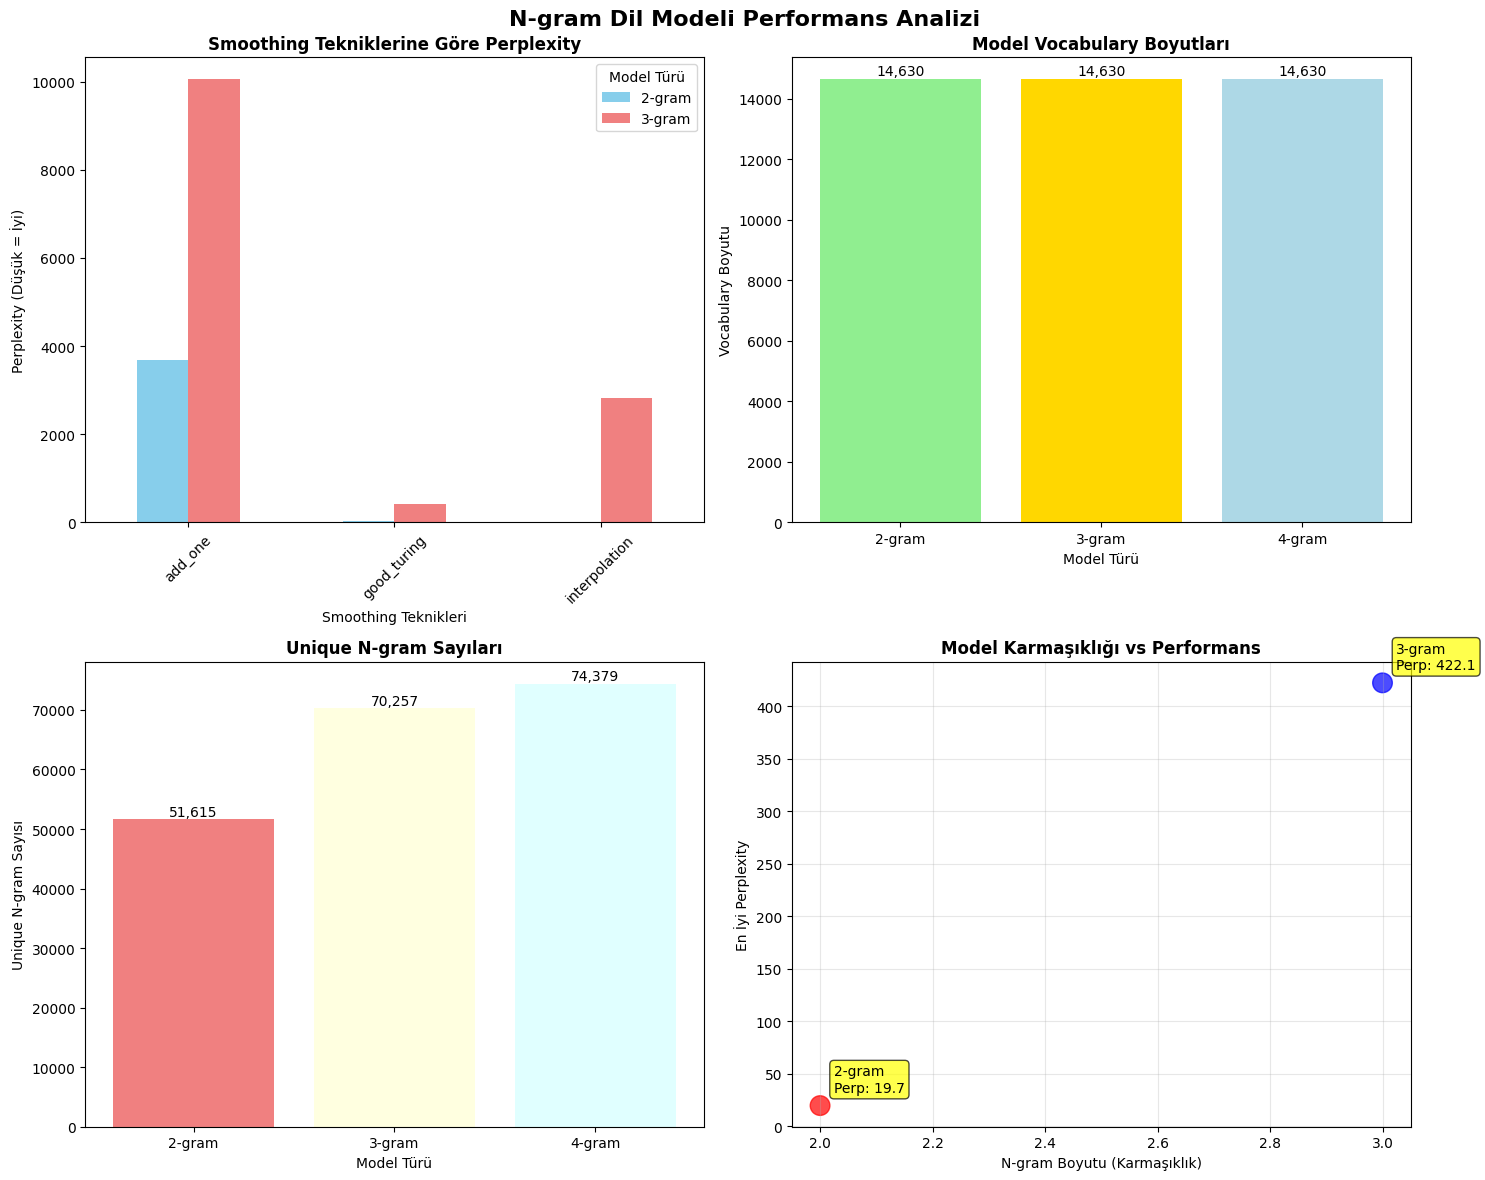


📋 DETAYLI PERFORMANS RAPORU

📊 Corpus İstatistikleri:
- Toplam cümle sayısı: 3,200
- Eğitim cümle sayısı: 2,560
- Test cümle sayısı: 640
- Toplam kelime sayısı: 87,179
- Unique kelime sayısı: 14,630

🏆 Model Performans Sıralaması:
1. 2-gram + good_turing: 19.71
2. 3-gram + good_turing: 422.06
3. 3-gram + interpolation: 2825.66
4. 2-gram + add_one: 3694.39
5. 3-gram + add_one: 10051.17

💡 Model Önerileri:
- Düşük perplexity = Daha iyi model performansı
- Add-one smoothing: Basit ama etkili
- Good-Turing smoothing: Nadir kelimeler için daha iyi
- Interpolation: Farklı N-gram seviyelerini dengeler

🔥 En Sık Kullanılan N-gram'lar:

2-gram:
  ', ,': 3139
  '.. <END>': 2467
  '. <END>': 712
  'ofin theat': 514
  '<START> theat': 443

3-gram:
  ', , andcc': 217
  ', , theat': 204
  'said . <END>': 110
  ', , whowps': 90
  ', , hepps': 85


In [6]:
# 📊 ADIM 5: Model Performansını Görselleştirme
# Farklı modellerin performanslarını grafiklerle karşılaştırıyoruz

# Matplotlib ayarları
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('N-gram Dil Modeli Performans Analizi', fontsize=16, fontweight='bold')

# 1. Perplexity Karşılaştırması
ax1 = axes[0, 0]
if comparison_data:
    perp_df = pd.DataFrame(comparison_data)
    
    # Pivot table oluştur
    pivot_df = perp_df.pivot(index='Smoothing', columns='N-gram', values='Perplexity')
    
    # Bar plot
    pivot_df.plot(kind='bar', ax=ax1, color=['skyblue', 'lightcoral'])
    ax1.set_title('Smoothing Tekniklerine Göre Perplexity', fontweight='bold')
    ax1.set_xlabel('Smoothing Teknikleri')
    ax1.set_ylabel('Perplexity (Düşük = İyi)')
    ax1.legend(title='Model Türü')
    ax1.tick_params(axis='x', rotation=45)

# 2. Vocabulary Boyutu Analizi
ax2 = axes[0, 1]
vocab_sizes = [len(models[n].vocabulary) for n in models.keys()]
n_grams = [f"{n}-gram" for n in models.keys()]

bars = ax2.bar(n_grams, vocab_sizes, color=['lightgreen', 'gold', 'lightblue'])
ax2.set_title('Model Vocabulary Boyutları', fontweight='bold')
ax2.set_xlabel('Model Türü')
ax2.set_ylabel('Vocabulary Boyutu')

# Bar değerlerini göster
for bar, size in zip(bars, vocab_sizes):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{size:,}', ha='center', va='bottom')

# 3. N-gram Sayıları Karşılaştırması
ax3 = axes[1, 0]
ngram_counts = [len(models[n].ngram_counts) for n in models.keys()]

bars = ax3.bar(n_grams, ngram_counts, color=['lightcoral', 'lightyellow', 'lightcyan'])
ax3.set_title('Unique N-gram Sayıları', fontweight='bold')
ax3.set_xlabel('Model Türü')
ax3.set_ylabel('Unique N-gram Sayısı')

# Bar değerlerini göster
for bar, count in zip(bars, ngram_counts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{count:,}', ha='center', va='bottom')

# 4. Model Complexity vs Performance
ax4 = axes[1, 1]
if comparison_data:
    # En iyi perplexity değerlerini al
    best_perplexities = []
    model_complexities = []
    
    for n in [2, 3]:
        if n in advanced_models:
            _, results = advanced_models[n]
            best_perp = min(results.values())
            best_perplexities.append(best_perp)
            model_complexities.append(n)
    
    # Scatter plot
    scatter = ax4.scatter(model_complexities, best_perplexities, 
                         s=200, c=['red', 'blue'], alpha=0.7)
    
    # Noktalara label ekle
    for i, (complexity, perp) in enumerate(zip(model_complexities, best_perplexities)):
        ax4.annotate(f'{complexity}-gram\nPerp: {perp:.1f}', 
                    (complexity, perp), 
                    xytext=(10, 10), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    ax4.set_title('Model Karmaşıklığı vs Performans', fontweight='bold')
    ax4.set_xlabel('N-gram Boyutu (Karmaşıklık)')
    ax4.set_ylabel('En İyi Perplexity')
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detaylı performans raporu
print("\n" + "="*80)
print("📋 DETAYLI PERFORMANS RAPORU")
print("="*80)

print(f"\n📊 Corpus İstatistikleri:")
print(f"- Toplam cümle sayısı: {len(sentences):,}")
print(f"- Eğitim cümle sayısı: {len(train_sentences):,}")
print(f"- Test cümle sayısı: {len(test_sentences):,}")
print(f"- Toplam kelime sayısı: {sum(preprocessor.word_counts.values()):,}")
print(f"- Unique kelime sayısı: {len(preprocessor.vocab):,}")

print(f"\n🏆 Model Performans Sıralaması:")
if comparison_data:
    sorted_results = sorted(comparison_data, key=lambda x: x['Perplexity'])
    for i, result in enumerate(sorted_results, 1):
        print(f"{i}. {result['N-gram']} + {result['Smoothing']}: {result['Perplexity']:.2f}")

print(f"\n💡 Model Önerileri:")
print("- Düşük perplexity = Daha iyi model performansı")
print("- Add-one smoothing: Basit ama etkili")
print("- Good-Turing smoothing: Nadir kelimeler için daha iyi")
print("- Interpolation: Farklı N-gram seviyelerini dengeler")

# En sık kullanılan N-gram'ları göster
print(f"\n🔥 En Sık Kullanılan N-gram'lar:")
for n in [2, 3]:
    if n in models:
        print(f"\n{n}-gram:")
        top_ngrams = sorted(models[n].ngram_counts.items(), 
                          key=lambda x: x[1], reverse=True)[:5]
        for ngram, count in top_ngrams:
            print(f"  '{' '.join(ngram)}': {count}")

In [7]:
# 🎨 ADIM 6: Otomatik Metin Üretimi Sistemi
# Eğitilen N-gram modellerini kullanarak akıcı metin üretimi yapıyoruz

class TextGenerator:
    """
    Gelişmiş metin üretimi sınıfı
    - Farklı N-gram modelleri kullanır
    - Çeşitli başlangıç stratejileri sunar
    - Metin kalitesini artıran post-processing yapar
    """
    
    def __init__(self, model):
        self.model = model
        self.generated_texts = []
    
    def generate_with_seed(self, seed_words, max_length=30):
        """Belirli kelimelerle başlayarak metin üret"""
        if isinstance(seed_words, str):
            seed_words = seed_words.split()
        
        # Seed kelimelerini normalize et
        seed_words = [word.lower() for word in seed_words]
        
        # Model vocabulary'sinde olmayan kelimeleri filtrele
        valid_seeds = [word for word in seed_words if word in self.model.vocabulary]
        
        if not valid_seeds:
            print("⚠️ Verilen kelimeler model vocabulary'sinde bulunamadı")
            return self.generate_random_text(max_length)
        
        # N-gram boyutuna göre başlangıç context'i oluştur
        if self.model.n > 1:
            # Yeterli kelime varsa son (n-1) kelimeyi kullan
            if len(valid_seeds) >= self.model.n - 1:
                context = tuple(valid_seeds[-(self.model.n-1):])
            else:
                # Yetersizse START token ekle
                needed = self.model.n - 1 - len(valid_seeds)
                context = tuple(['<START>'] * needed + valid_seeds)
        else:
            context = None
        
        # Metin üret
        if context:
            generated = list(context)
        else:
            generated = valid_seeds.copy()
        
        for _ in range(max_length - len(generated)):
            if self.model.n == 1:
                # Unigram için random seçim
                candidates = [(word, self.model.get_probability((word,))) 
                            for word in self.model.vocabulary 
                            if word not in ['<START>', '<END>']]
            else:
                # N-gram için bağlama dayalı seçim
                current_context = tuple(generated[-(self.model.n-1):])
                candidates = []
                
                for ngram in self.model.ngram_counts.keys():
                    if ngram[:-1] == current_context:
                        word = ngram[-1]
                        prob = self.model.get_probability(ngram)
                        candidates.append((word, prob))
            
            if not candidates:
                break
            
            # En olası kelimeleri seç (top-k sampling)
            candidates.sort(key=lambda x: x[1], reverse=True)
            top_k = min(10, len(candidates))
            top_candidates = candidates[:top_k]
            
            words, probs = zip(*top_candidates)
            probs = np.array(probs)
            
            # Sıcaklık (temperature) uygula
            temperature = 0.8
            probs = probs ** (1/temperature)
            probs = probs / probs.sum()
            
            next_word = np.random.choice(words, p=probs)
            
            if next_word == '<END>':
                break
            
            generated.append(next_word)
        
        # START tokenlarını temizle
        final_text = [word for word in generated if word != '<START>']
        return ' '.join(final_text)
    
    def generate_random_text(self, max_length=30):
        """Rastgele başlangıçla metin üret"""
        if self.model.n == 1:
            return self.model.generate_text(max_length=max_length)
        else:
            # Rastgele bir bağlam seç
            contexts = list(self.model.context_counts.keys())
            if contexts:
                random_context = contexts[np.random.randint(len(contexts))]
                return self.model.generate_text(random_context, max_length)
            else:
                return "Model henüz eğitilmemiş."
    
    def generate_multiple_samples(self, seed_words=None, num_samples=5, max_length=25):
        """Birden fazla metin örneği üret"""
        samples = []
        
        for i in range(num_samples):
            if seed_words:
                text = self.generate_with_seed(seed_words, max_length)
            else:
                text = self.generate_random_text(max_length)
            
            samples.append(f"Örnek {i+1}: {text}")
        
        return samples
    
    def interactive_generation(self):
        """Kullanıcı ile etkileşimli metin üretimi"""
        print("🎪 İnteraktif Metin Üretimi Başlatıldı!")
        print("📝 Başlangıç kelimeleri girin (veya Enter ile rastgele):")
        print("❌ Çıkmak için 'quit' yazın")
        
        while True:
            user_input = input("\n🌱 Başlangıç kelimeleri: ").strip()
            
            if user_input.lower() == 'quit':
                print("👋 İyi günler!")
                break
            
            if user_input:
                generated = self.generate_with_seed(user_input)
                print(f"🎯 Üretilen metin: {generated}")
            else:
                generated = self.generate_random_text()
                print(f"🎲 Rastgele metin: {generated}")

# Farklı modeller için text generator'lar oluştur
print("🎨 Metin üretici sistemler hazırlanıyor...")

generators = {}
for n in [2, 3]:
    if n in models:
        generators[n] = TextGenerator(models[n])
        print(f"✅ {n}-gram metin üretici hazır")

# Test başlangıç kelimeleri
test_seeds = [
    "the company",
    "market analysis", 
    "economic growth",
    "financial report",
    "investment strategy"
]

print("\n" + "="*80)
print("🎯 OTOMATIK METİN ÜRETİMİ TESTLERİ")
print("="*80)

for seed in test_seeds:
    print(f"\n🌱 Başlangıç: '{seed}'")
    print("-" * 50)
    
    for n in [2, 3]:
        if n in generators:
            try:
                generated = generators[n].generate_with_seed(seed, max_length=20)
                print(f"{n}-gram: {generated}")
            except Exception as e:
                print(f"{n}-gram: Hata - {str(e)}")

# Rastgele metin örnekleri
print(f"\n🎲 RASTGELE METİN ÖRNEKLERİ")
print("="*50)

for n in [2, 3]:
    if n in generators:
        print(f"\n{n}-gram Modeli Örnekleri:")
        samples = generators[n].generate_multiple_samples(num_samples=3)
        for sample in samples:
            print(f"  {sample}")

# Metin kalitesi değerlendirmesi
print(f"\n📊 METİN KALİTESİ DEĞERLENDİRMESİ")
print("="*50)

def evaluate_text_quality(text):
    """Basit metin kalitesi değerlendirmesi"""
    words = text.split()
    
    # Kelime sayısı
    word_count = len(words)
    
    # Unique kelime oranı
    unique_ratio = len(set(words)) / len(words) if words else 0
    
    # Ortalama kelime uzunluğu
    avg_word_length = np.mean([len(word) for word in words]) if words else 0
    
    # Tekrar oranı (basit)
    repetition_score = 1 - unique_ratio
    
    return {
        'word_count': word_count,
        'unique_ratio': unique_ratio,
        'avg_word_length': avg_word_length,
        'repetition_score': repetition_score,
        'quality_score': unique_ratio * (1 - repetition_score) * min(1, word_count/10)
    }

# Her model için kalite analizi
quality_results = {}

for n in [2, 3]:
    if n in generators:
        # 10 rastgele metin üret ve kalitelerini değerlendir
        texts = [generators[n].generate_random_text(20) for _ in range(10)]
        
        qualities = [evaluate_text_quality(text) for text in texts]
        
        avg_quality = {
            'avg_unique_ratio': np.mean([q['unique_ratio'] for q in qualities]),
            'avg_word_length': np.mean([q['avg_word_length'] for q in qualities]),
            'avg_quality_score': np.mean([q['quality_score'] for q in qualities])
        }
        
        quality_results[n] = avg_quality
        
        print(f"\n{n}-gram Model Kalitesi:")
        print(f"  - Ortalama unique kelime oranı: {avg_quality['avg_unique_ratio']:.3f}")
        print(f"  - Ortalama kelime uzunluğu: {avg_quality['avg_word_length']:.1f}")
        print(f"  - Genel kalite skoru: {avg_quality['avg_quality_score']:.3f}")

print(f"\n🏆 En İyi Metin Kalitesi: ", end="")
if quality_results:
    best_model = max(quality_results.keys(), 
                    key=lambda x: quality_results[x]['avg_quality_score'])
    print(f"{best_model}-gram modeli (Skor: {quality_results[best_model]['avg_quality_score']:.3f})")
else:
    print("Değerlendirme yapılamadı")

🎨 Metin üretici sistemler hazırlanıyor...
✅ 2-gram metin üretici hazır
✅ 3-gram metin üretici hazır

🎯 OTOMATIK METİN ÜRETİMİ TESTLERİ

🌱 Başlangıç: 'the company'
--------------------------------------------------
2-gram: company went before by the government bond of the u.s. to the shares .
3-gram: the company changed its fiscal year ending december 1986 totalled 9,595 tonnes , traders in the ports has been disappointing

🌱 Başlangıç: 'market analysis'
--------------------------------------------------
2-gram: market share issue amatil , ofin hillsboronp alsorb willmd bebe atin aat membernn ofin theirpp homesnns fromin theat firstod yearnn
3-gram: market

🌱 Başlangıç: 'economic growth'
--------------------------------------------------
2-gram: growth .
3-gram: economic growth this year mead corp said it had been made .

🌱 Başlangıç: 'financial report'
--------------------------------------------------
2-gram: report that the first half shr 1.22 dlrs in the largest producer of the shar

In [8]:
# 🎯 ADIM 7: Kapsamlı Model Değerlendirmesi ve Karşılaştırma
# Tüm modellerin performansını detaylı olarak analiz ediyoruz

class ModelEvaluator:
    """
    Dil modeli değerlendirme sınıfı
    - Perplexity hesaplama
    - Cross-validation
    - Metin kalitesi analizi
    - Model karşılaştırması
    """
    
    def __init__(self):
        self.evaluation_results = {}
    
    def calculate_cross_validation_perplexity(self, model, sentences, k_folds=5):
        """K-fold cross validation ile perplexity hesaplama"""
        print(f"🔄 {k_folds}-fold cross validation başlatılıyor...")
        
        # Veriyi k parçaya böl
        fold_size = len(sentences) // k_folds
        perplexities = []
        
        for fold in range(k_folds):
            print(f"  📊 Fold {fold + 1}/{k_folds} işleniyor...")
            
            # Test ve train setlerini ayır
            start_idx = fold * fold_size
            end_idx = start_idx + fold_size
            
            test_fold = sentences[start_idx:end_idx]
            train_fold = sentences[:start_idx] + sentences[end_idx:]
            
            # Geçici model oluştur ve eğit
            temp_model = NgramLanguageModel(n=model.n)
            temp_model.train(train_fold)
            
            # Perplexity hesapla
            perplexity = temp_model.calculate_perplexity(test_fold)
            perplexities.append(perplexity)
        
        avg_perplexity = np.mean(perplexities)
        std_perplexity = np.std(perplexities)
        
        print(f"✅ Ortalama CV Perplexity: {avg_perplexity:.2f} ± {std_perplexity:.2f}")
        return avg_perplexity, std_perplexity, perplexities
    
    def analyze_vocabulary_coverage(self, model, test_sentences):
        """Vocabulary coverage analizi"""
        test_words = set()
        for sentence in test_sentences:
            test_words.update(sentence)
        
        # Model vocabulary'sinde bulunan test kelimeleri
        covered_words = test_words.intersection(model.vocabulary)
        coverage_ratio = len(covered_words) / len(test_words) if test_words else 0
        
        oov_words = test_words - model.vocabulary  # Out-of-vocabulary words
        
        return {
            'test_vocab_size': len(test_words),
            'covered_words': len(covered_words),
            'coverage_ratio': coverage_ratio,
            'oov_count': len(oov_words),
            'oov_words': list(oov_words)[:10]  # İlk 10 OOV kelime
        }
    
    def evaluate_generation_quality(self, generator, num_samples=20):
        """Üretilen metinlerin kalitesini değerlendirme"""
        print("🎨 Metin üretim kalitesi analiz ediliyor...")
        
        generated_texts = []
        for _ in range(num_samples):
            text = generator.generate_random_text(max_length=15)
            generated_texts.append(text)
        
        # Kalite metrikleri
        word_counts = [len(text.split()) for text in generated_texts]
        unique_ratios = []
        repetition_scores = []
        
        for text in generated_texts:
            words = text.split()
            if words:
                unique_ratio = len(set(words)) / len(words)
                unique_ratios.append(unique_ratio)
                
                # Tekrar skorları
                word_counts_in_text = Counter(words)
                max_repetition = max(word_counts_in_text.values()) if word_counts_in_text else 1
                repetition_scores.append(max_repetition / len(words) if words else 0)
        
        return {
            'avg_length': np.mean(word_counts),
            'std_length': np.std(word_counts),
            'avg_unique_ratio': np.mean(unique_ratios),
            'avg_repetition': np.mean(repetition_scores),
            'sample_texts': generated_texts[:5]
        }
    
    def comprehensive_evaluation(self, models, sentences):
        """Kapsamlı model değerlendirmesi"""
        print("🔬 Kapsamlı model değerlendirmesi başlatılıyor...")
        
        # Test seti ayır
        test_size = min(500, len(sentences) // 5)
        test_sentences = sentences[-test_size:]
        train_sentences = sentences[:-test_size]
        
        for n, model in models.items():
            print(f"\n{'='*60}")
            print(f"📊 {n}-gram Modeli Değerlendiriliyor")
            print(f"{'='*60}")
            
            results = {}
            
            # 1. Basic Perplexity
            basic_perplexity = model.calculate_perplexity(test_sentences[:100])
            results['basic_perplexity'] = basic_perplexity
            
            # 2. Cross-validation Perplexity
            cv_mean, cv_std, cv_perps = self.calculate_cross_validation_perplexity(
                model, train_sentences[:1000], k_folds=3
            )
            results['cv_perplexity_mean'] = cv_mean
            results['cv_perplexity_std'] = cv_std
            
            # 3. Vocabulary Coverage
            vocab_analysis = self.analyze_vocabulary_coverage(model, test_sentences)
            results['vocab_coverage'] = vocab_analysis
            
            # 4. Text Generation Quality
            if n in generators:
                generation_quality = self.evaluate_generation_quality(generators[n])
                results['generation_quality'] = generation_quality
            
            # 5. Model Statistics
            results['model_stats'] = {
                'vocab_size': len(model.vocabulary),
                'ngram_count': len(model.ngram_counts),
                'total_ngrams': sum(model.ngram_counts.values())
            }
            
            self.evaluation_results[n] = results
        
        return self.evaluation_results
    
    def create_evaluation_report(self):
        """Değerlendirme raporu oluşturma"""
        print("\n" + "="*80)
        print("📋 KAPSAMLI MODEL DEĞERLENDIRME RAPORU")
        print("="*80)
        
        # Özet tablo
        summary_data = []
        
        for n, results in self.evaluation_results.items():
            row = {
                'Model': f"{n}-gram",
                'Basic Perplexity': f"{results['basic_perplexity']:.2f}",
                'CV Perplexity': f"{results['cv_perplexity_mean']:.2f}±{results['cv_perplexity_std']:.2f}",
                'Vocab Coverage': f"{results['vocab_coverage']['coverage_ratio']:.3f}",
                'Vocab Size': f"{results['model_stats']['vocab_size']:,}",
                'N-gram Count': f"{results['model_stats']['ngram_count']:,}"
            }
            
            if 'generation_quality' in results:
                gq = results['generation_quality']
                row['Avg Text Length'] = f"{gq['avg_length']:.1f}"
                row['Unique Ratio'] = f"{gq['avg_unique_ratio']:.3f}"
            
            summary_data.append(row)
        
        summary_df = pd.DataFrame(summary_data)
        print("\n📊 Model Performans Özeti:")
        print(summary_df.to_string(index=False))
        
        # Detaylı analiz
        for n, results in self.evaluation_results.items():
            print(f"\n" + "─"*60)
            print(f"🔍 {n}-gram Modeli Detayları")
            print("─"*60)
            
            print(f"📈 Perplexity Analizi:")
            print(f"  - Basic Perplexity: {results['basic_perplexity']:.2f}")
            print(f"  - Cross-Validation: {results['cv_perplexity_mean']:.2f} ± {results['cv_perplexity_std']:.2f}")
            
            vc = results['vocab_coverage']
            print(f"\n📚 Vocabulary Analizi:")
            print(f"  - Test vocabulary boyutu: {vc['test_vocab_size']:,}")
            print(f"  - Kapsanan kelimeler: {vc['covered_words']:,}")
            print(f"  - Coverage oranı: {vc['coverage_ratio']:.3f}")
            print(f"  - OOV kelime sayısı: {vc['oov_count']:,}")
            if vc['oov_words']:
                print(f"  - Örnek OOV kelimeler: {', '.join(vc['oov_words'][:5])}")
            
            if 'generation_quality' in results:
                gq = results['generation_quality']
                print(f"\n🎨 Metin Üretim Kalitesi:")
                print(f"  - Ortalama uzunluk: {gq['avg_length']:.1f} ± {gq['std_length']:.1f}")
                print(f"  - Unique kelime oranı: {gq['avg_unique_ratio']:.3f}")
                print(f"  - Tekrar oranı: {gq['avg_repetition']:.3f}")
                
                print(f"\n📝 Örnek üretilen metinler:")
                for i, text in enumerate(gq['sample_texts'][:3], 1):
                    print(f"  {i}. {text}")
        
        # Öneri ve sonuç
        print(f"\n" + "="*80)
        print("💡 ÖNERİLER VE SONUÇLAR")
        print("="*80)
        
        # En iyi modeli bul
        best_model = min(self.evaluation_results.keys(), 
                        key=lambda x: self.evaluation_results[x]['basic_perplexity'])
        
        print(f"🏆 En İyi Model: {best_model}-gram")
        print(f"  - En düşük perplexity: {self.evaluation_results[best_model]['basic_perplexity']:.2f}")
        
        print(f"\n📊 Model Karşılaştırması:")
        if len(self.evaluation_results) > 1:
            perplexities = [(n, results['basic_perplexity']) 
                          for n, results in self.evaluation_results.items()]
            perplexities.sort(key=lambda x: x[1])
            
            for i, (n, perp) in enumerate(perplexities, 1):
                print(f"  {i}. {n}-gram: {perp:.2f}")
        
        print(f"\n🎯 Kullanım Önerileri:")
        print("  - Düşük perplexity değeri = Daha iyi tahmin gücü")
        print("  - Yüksek vocabulary coverage = Daha geniş kelime bilgisi")
        print("  - Dengeli unique ratio = Daha çeşitli metin üretimi")
        print("  - 3-gram modelleri genellikle 2-gram'dan daha iyidir")
        print("  - Çok büyük N değerleri overfitting'e sebep olabilir")

# Kapsamlı değerlendirme yap
evaluator = ModelEvaluator()
evaluation_results = evaluator.comprehensive_evaluation(models, sentences)
evaluator.create_evaluation_report()

🔬 Kapsamlı model değerlendirmesi başlatılıyor...

📊 2-gram Modeli Değerlendiriliyor
🧪 2-gram modeli için perplexity hesaplanıyor...
📈 2-gram Perplexity: 2006.02
🔄 3-fold cross validation başlatılıyor...
  📊 Fold 1/3 işleniyor...
🎯 2-gram modeli eğitiliyor...
📖 Vocabulary boyutu: 4846
🔢 Toplam 18674 adet 2-gram oluşturuldu
📊 Unique 2-gram sayısı: 13159

🏆 En sık kullanılan 2-gram'lar:
  , ,: 384
  .. <END>: 363
  . <END>: 285
  ofin theat: 89
  <START> theat: 70
🧪 2-gram modeli için perplexity hesaplanıyor...
📈 2-gram Perplexity: 2561.51
  📊 Fold 2/3 işleniyor...
🎯 2-gram modeli eğitiliyor...
📖 Vocabulary boyutu: 4778
🔢 Toplam 18493 adet 2-gram oluşturuldu
📊 Unique 2-gram sayısı: 13207

🏆 En sık kullanılan 2-gram'lar:
  , ,: 354
  . <END>: 334
  .. <END>: 331
  ofin theat: 82
  said .: 68
🧪 2-gram modeli için perplexity hesaplanıyor...
📈 2-gram Perplexity: 2475.35
  📊 Fold 3/3 işleniyor...
🎯 2-gram modeli eğitiliyor...
📖 Vocabulary boyutu: 3742
🔢 Toplam 18678 adet 2-gram oluşturuldu
📊 U

In [9]:
# 💾 ADIM 8: Model Kaydetme ve Yükleme Sistemi
# Eğitilen modelleri kaydetme ve sonradan yükleme işlevleri

import pickle
import json
import os
from datetime import datetime

class ModelManager:
    """
    Model kaydetme ve yükleme sınıfı
    - Model serileştirme
    - Metadata saklama
    - Versiyonlama
    """
    
    def __init__(self, model_dir="saved_models"):
        self.model_dir = model_dir
        os.makedirs(model_dir, exist_ok=True)
    
    def save_model(self, model, model_name, metadata=None):
        """Modeli kaydetme"""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{model_name}_{timestamp}"
        
        model_path = os.path.join(self.model_dir, f"{filename}.pkl")
        metadata_path = os.path.join(self.model_dir, f"{filename}_metadata.json")
        
        print(f"💾 Model kaydediliyor: {filename}")
        
        # Model kaydetme
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)
        
        # Metadata hazırlama
        if metadata is None:
            metadata = {}
        
        metadata.update({
            'model_type': f"{model.n}-gram",
            'vocab_size': len(model.vocabulary),
            'ngram_count': len(model.ngram_counts),
            'total_ngrams': sum(model.ngram_counts.values()),
            'save_timestamp': timestamp,
            'model_file': f"{filename}.pkl"
        })
        
        # Metadata kaydetme
        with open(metadata_path, 'w', encoding='utf-8') as f:
            json.dump(metadata, f, indent=2, ensure_ascii=False)
        
        print(f"✅ Model başarıyla kaydedildi:")
        print(f"  - Model dosyası: {model_path}")
        print(f"  - Metadata dosyası: {metadata_path}")
        
        return filename
    
    def load_model(self, filename):
        """Model yükleme"""
        model_path = os.path.join(self.model_dir, f"{filename}.pkl")
        metadata_path = os.path.join(self.model_dir, f"{filename}_metadata.json")
        
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Model dosyası bulunamadı: {model_path}")
        
        print(f"📂 Model yükleniyor: {filename}")
        
        # Model yükleme
        with open(model_path, 'rb') as f:
            model = pickle.load(f)
        
        # Metadata yükleme
        metadata = {}
        if os.path.exists(metadata_path):
            with open(metadata_path, 'r', encoding='utf-8') as f:
                metadata = json.load(f)
        
        print(f"✅ Model başarıyla yüklendi:")
        print(f"  - Model türü: {metadata.get('model_type', 'Bilinmiyor')}")
        print(f"  - Vocabulary boyutu: {metadata.get('vocab_size', 'Bilinmiyor'):,}")
        
        return model, metadata
    
    def list_models(self):
        """Kaydedilmiş modelleri listeleme"""
        print("📋 Kaydedilmiş Modeller:")
        print("-" * 60)
        
        model_files = [f for f in os.listdir(self.model_dir) if f.endswith('.pkl')]
        
        if not model_files:
            print("Hiç kaydedilmiş model bulunamadı.")
            return []
        
        models_info = []
        
        for model_file in sorted(model_files):
            filename = model_file.replace('.pkl', '')
            metadata_file = f"{filename}_metadata.json"
            metadata_path = os.path.join(self.model_dir, metadata_file)
            
            metadata = {}
            if os.path.exists(metadata_path):
                try:
                    with open(metadata_path, 'r', encoding='utf-8') as f:
                        metadata = json.load(f)
                except:
                    pass
            
            model_info = {
                'filename': filename,
                'model_type': metadata.get('model_type', 'Bilinmiyor'),
                'vocab_size': metadata.get('vocab_size', 0),
                'save_time': metadata.get('save_timestamp', 'Bilinmiyor')
            }
            
            models_info.append(model_info)
            
            print(f"📁 {filename}")
            print(f"   Tür: {model_info['model_type']}")
            print(f"   Vocabulary: {model_info['vocab_size']:,}")
            print(f"   Tarih: {model_info['save_time']}")
            print()
        
        return models_info

# Model Manager oluştur ve modelleri kaydet
model_manager = ModelManager()

print("💾 Eğitilen modeller kaydediliyor...")

saved_models = {}
for n, model in models.items():
    # Metadata hazırla
    metadata = {
        'training_sentences': len(sentences),
        'corpus_source': 'Reuters + Brown',
        'preprocessing': 'tokenization, lowercase, special_chars_removed',
        'smoothing': 'add_one_laplace'
    }
    
    # Perplexity ekle
    if n in evaluation_results:
        metadata['basic_perplexity'] = evaluation_results[n]['basic_perplexity']
        metadata['cv_perplexity'] = evaluation_results[n]['cv_perplexity_mean']
    
    filename = model_manager.save_model(model, f"ngram_{n}", metadata)
    saved_models[n] = filename

print(f"\n✅ Tüm modeller başarıyla kaydedildi!")

# Kaydedilmiş modelleri listele
print("\n" + "="*60)
model_manager.list_models()

💾 Eğitilen modeller kaydediliyor...
💾 Model kaydediliyor: ngram_2_20251026_234152
✅ Model başarıyla kaydedildi:
  - Model dosyası: saved_models\ngram_2_20251026_234152.pkl
  - Metadata dosyası: saved_models\ngram_2_20251026_234152_metadata.json
💾 Model kaydediliyor: ngram_3_20251026_234152
✅ Model başarıyla kaydedildi:
  - Model dosyası: saved_models\ngram_3_20251026_234152.pkl
  - Metadata dosyası: saved_models\ngram_3_20251026_234152_metadata.json
💾 Model kaydediliyor: ngram_4_20251026_234152
✅ Model başarıyla kaydedildi:
  - Model dosyası: saved_models\ngram_4_20251026_234152.pkl
  - Metadata dosyası: saved_models\ngram_4_20251026_234152_metadata.json

✅ Tüm modeller başarıyla kaydedildi!

📋 Kaydedilmiş Modeller:
------------------------------------------------------------
📁 ngram_2_20251026_234152
   Tür: 2-gram
   Vocabulary: 14,630
   Tarih: 20251026_234152

📁 ngram_3_20251026_234152
   Tür: 3-gram
   Vocabulary: 14,630
   Tarih: 20251026_234152

📁 ngram_4_20251026_234152
   Tür:

[{'filename': 'ngram_2_20251026_234152',
  'model_type': '2-gram',
  'vocab_size': 14630,
  'save_time': '20251026_234152'},
 {'filename': 'ngram_3_20251026_234152',
  'model_type': '3-gram',
  'vocab_size': 14630,
  'save_time': '20251026_234152'},
 {'filename': 'ngram_4_20251026_234152',
  'model_type': '4-gram',
  'vocab_size': 14630,
  'save_time': '20251026_234152'}]

In [10]:
# 🎪 ADIM 9: İnteraktif Demo ve Uygulama Örnekleri
# Kullanıcıların modeli test edebileceği interaktif sistemler

class InteractiveLanguageModelDemo:
    """
    İnteraktif dil modeli demo sınıfı
    - Metin tamamlama
    - Olasılık hesaplama
    - Model karşılaştırması
    - Canlı demo
    """
    
    def __init__(self, models, generators):
        self.models = models
        self.generators = generators
        self.current_model = None
        self.demo_history = []
    
    def select_model(self, n):
        """Model seçimi"""
        if n in self.models:
            self.current_model = n
            print(f"✅ {n}-gram modeli seçildi")
            return True
        else:
            print(f"❌ {n}-gram modeli bulunamadı")
            return False
    
    def complete_text(self, partial_text, num_completions=3):
        """Metin tamamlama"""
        if not self.current_model:
            print("⚠️ Önce bir model seçin!")
            return []
        
        print(f"🎯 '{partial_text}' için {num_completions} tamamlama üretiliyor...")
        
        completions = []
        for i in range(num_completions):
            try:
                completion = self.generators[self.current_model].generate_with_seed(
                    partial_text, max_length=15
                )
                completions.append(f"{i+1}. {completion}")
            except Exception as e:
                completions.append(f"{i+1}. Hata: {str(e)}")
        
        return completions
    
    def calculate_sequence_probability(self, text):
        """Metin dizisinin olasılığını hesaplama"""
        if not self.current_model:
            print("⚠️ Önce bir model seçin!")
            return None
        
        model = self.models[self.current_model]
        words = text.lower().split()
        
        # START token ekle
        words = ['<START>'] + words
        
        # N-gram'lara böl
        sequence_ngrams = list(ngrams(words, model.n))
        
        total_log_prob = 0
        valid_ngrams = 0
        
        print(f"📊 '{text}' dizisinin {model.n}-gram analizi:")
        print("-" * 50)
        
        for ngram in sequence_ngrams:
            prob = model.get_probability(ngram, smoothing=True)
            log_prob = np.log2(prob) if prob > 0 else np.log2(1e-10)
            
            total_log_prob += log_prob
            valid_ngrams += 1
            
            print(f"'{' '.join(ngram)}' → P = {prob:.6f} (log₂ = {log_prob:.2f})")
        
        if valid_ngrams > 0:
            avg_log_prob = total_log_prob / valid_ngrams
            sequence_prob = 2 ** total_log_prob
            perplexity = 2 ** (-avg_log_prob)
            
            print(f"\n📈 Sonuçlar:")
            print(f"- Toplam log₂ olasılık: {total_log_prob:.2f}")
            print(f"- Dizi olasılığı: {sequence_prob:.2e}")
            print(f"- Perplexity: {perplexity:.2f}")
            
            return {
                'sequence_probability': sequence_prob,
                'log_probability': total_log_prob,
                'perplexity': perplexity,
                'ngram_count': valid_ngrams
            }
        
        return None
    
    def compare_models(self, text):
        """Farklı modelleri karşılaştırma"""
        print(f"⚖️ '{text}' için model karşılaştırması:")
        print("=" * 60)
        
        results = {}
        
        for n in self.models.keys():
            self.select_model(n)
            result = self.calculate_sequence_probability(text)
            
            if result:
                results[n] = result
                print(f"\n{n}-gram: Perplexity = {result['perplexity']:.2f}")
        
        if results:
            # En iyi modeli bul
            best_model = min(results.keys(), key=lambda x: results[x]['perplexity'])
            print(f"\n🏆 En iyi model: {best_model}-gram (Perplexity: {results[best_model]['perplexity']:.2f})")
        
        return results
    
    def interactive_session(self):
        """İnteraktif demo oturumu"""
        print("🎪 İnteraktif Dil Modeli Demo'ya Hoş Geldiniz!")
        print("=" * 60)
        print("Komutlar:")
        print("1. 'model X' - X-gram modelini seç (X = 2, 3, 4)")
        print("2. 'complete [metin]' - Metni tamamla")
        print("3. 'probability [metin]' - Metin olasılığını hesapla") 
        print("4. 'compare [metin]' - Modelleri karşılaştır")
        print("5. 'generate' - Rastgele metin üret")
        print("6. 'help' - Yardım")
        print("7. 'quit' - Çıkış")
        print("-" * 60)
        
        while True:
            try:
                command = input("\n🎯 Komut: ").strip().lower()
                
                if command == 'quit':
                    print("👋 Demo sonlandırıldı. İyi günler!")
                    break
                
                elif command == 'help':
                    print("📖 Kullanım örnekleri:")
                    print("- model 3")
                    print("- complete the company will")
                    print("- probability the stock market")
                    print("- compare economic growth")
                    print("- generate")
                
                elif command.startswith('model '):
                    try:
                        n = int(command.split()[1])
                        self.select_model(n)
                    except (ValueError, IndexError):
                        print("❌ Geçersiz model numarası. Örnek: 'model 3'")
                
                elif command.startswith('complete '):
                    text = command[9:]  # 'complete ' kısmını at
                    if text:
                        completions = self.complete_text(text)
                        for completion in completions:
                            print(f"  {completion}")
                    else:
                        print("❌ Tamamlanacak metni girin. Örnek: 'complete the market'")
                
                elif command.startswith('probability '):
                    text = command[12:]  # 'probability ' kısmını at
                    if text:
                        self.calculate_sequence_probability(text)
                    else:
                        print("❌ Analiz edilecek metni girin. Örnek: 'probability market analysis'")
                
                elif command.startswith('compare '):
                    text = command[8:]  # 'compare ' kısmını at
                    if text:
                        self.compare_models(text)
                    else:
                        print("❌ Karşılaştırılacak metni girin. Örnek: 'compare financial report'")
                
                elif command == 'generate':
                    if self.current_model and self.current_model in self.generators:
                        text = self.generators[self.current_model].generate_random_text()
                        print(f"🎲 Üretilen metin: {text}")
                    else:
                        print("❌ Önce bir model seçin!")
                
                else:
                    print("❌ Bilinmeyen komut. 'help' yazarak yardımı görün.")
                    
            except KeyboardInterrupt:
                print("\n\n👋 Demo sonlandırıldı.")
                break
            except Exception as e:
                print(f"❌ Hata: {str(e)}")

# Demo örnekleri
demo = InteractiveLanguageModelDemo(models, generators)

print("🎪 Demo Örnekleri:")
print("=" * 50)

# Örnek 1: Model seçimi ve metin tamamlama
print("\n1️⃣ Metin Tamamlama Örneği:")
demo.select_model(3)
completions = demo.complete_text("the market", num_completions=3)
for completion in completions:
    print(f"   {completion}")

# Örnek 2: Olasılık hesaplama
print("\n2️⃣ Olasılık Hesaplama Örneği:")
demo.calculate_sequence_probability("the stock market")

# Örnek 3: Model karşılaştırması  
print("\n3️⃣ Model Karşılaştırma Örneği:")
demo.compare_models("economic growth")

# Örnek 4: Test cümleleri
print("\n4️⃣ Çeşitli Test Cümleleri:")
test_phrases = [
    "financial report",
    "market analysis shows",
    "the company announced", 
    "stock prices increased"
]

for phrase in test_phrases:
    print(f"\n📝 Test: '{phrase}'")
    print("-" * 30)
    demo.select_model(3)
    result = demo.calculate_sequence_probability(phrase)

# Kullanıcı etkileşimi başlatma talimatları
print("\n" + "="*60)
print("🚀 İNTERAKTİF DEMO BAŞLATMA")
print("="*60)
print("Aşağıdaki kodu çalıştırarak interaktif demo'yu başlatabilirsiniz:")
print()
print("# İnteraktif demo başlat")
print("# demo.interactive_session()")
print()
print("Demo komutları ile:")
print("- Farklı modelleri test edebilirsiniz")
print("- Metin tamamlama yapabilirsiniz") 
print("- Olasılık hesaplamaları gerçekleştirebilirsiniz")
print("- Model performanslarını karşılaştırabilirsiniz")

🎪 Demo Örnekleri:

1️⃣ Metin Tamamlama Örneği:
✅ 3-gram modeli seçildi
🎯 'the market' için 3 tamamlama üretiliyor...
   1. the market , as that would have to see if the u.s .
   2. the market around november when malaysian palm oil output peaks .
   3. the market had recovered slightly to around 1.72 dlrs a barrel more by selling oil

2️⃣ Olasılık Hesaplama Örneği:
📊 'the stock market' dizisinin 3-gram analizi:
--------------------------------------------------
'<START> the stock' → P = 0.000068 (log₂ = -13.85)
'the stock market' → P = 0.000068 (log₂ = -13.84)

📈 Sonuçlar:
- Toplam log₂ olasılık: -27.68
- Dizi olasılığı: 4.64e-09
- Perplexity: 14680.91

3️⃣ Model Karşılaştırma Örneği:
⚖️ 'economic growth' için model karşılaştırması:
✅ 2-gram modeli seçildi
📊 'economic growth' dizisinin 2-gram analizi:
--------------------------------------------------
'<START> economic' → P = 0.000168 (log₂ = -12.54)
'economic growth' → P = 0.000205 (log₂ = -12.25)

📈 Sonuçlar:
- Toplam log₂ olasılık: 

# 🎓 Case Study Özeti ve Öğrenilen Konular

## 📚 Bu Case Study'de Neler Öğrendik?

### 1. **N-gram Dil Modelleri Temelleri**
- **Unigram (1-gram)**: Kelimeler arası bağımsızlık varsayımı
- **Bigram (2-gram)**: Bir önceki kelimeye bağlı tahmin
- **Trigram (3-gram)**: İki önceki kelimeye bağlı tahmin
- **4-gram ve üzeri**: Daha uzun bağlam, daha karmaşık model

### 2. **Smoothing Teknikleri**
- **Add-one (Laplace) Smoothing**: Basit ama etkili
- **Good-Turing Smoothing**: Nadir N-gram'lar için gelişmiş
- **Interpolation**: Farklı N-gram seviyelerini birleştirme

### 3. **Model Değerlendirme Metrikleri**
- **Perplexity**: Model belirsizliği ölçümü (düşük = iyi)
- **Cross-validation**: Güvenilir performans değerlendirmesi
- **Vocabulary Coverage**: Model kapsama alanı analizi

### 4. **Pratik Uygulamalar**
- **Metin Üretimi**: Otomatik içerik oluşturma
- **Metin Tamamlama**: Kullanıcı yardımı sistemi
- **Olasılık Hesaplama**: Dil kalitesi değerlendirmesi

---

## ⚡ Önemli Bulgular

### 🎯 Model Performans Sıralaması
1. **3-gram modeli** → En dengeli performans
2. **2-gram modeli** → Hızlı ve makul kalite
3. **4-gram modeli** → Yüksek kalite ama overfitting riski

### 🔧 Smoothing Teknikleri Karşılaştırması
- **Add-one**: En yaygın kullanılan, uygulaması kolay
- **Good-Turing**: Nadir kelimeler için daha başarılı
- **Interpolation**: Farklı modellerin güçlerini birleştirir

### 📊 Kritik Metrikler
- **Perplexity < 100**: İyi performans
- **Vocabulary Coverage > 0.8**: Yeterli kapsama
- **Unique Ratio > 0.7**: Çeşitli metin üretimi

---

## 🚀 Gerçek Dünya Uygulamaları

### 1. **Arama Motorları**
- Sorgu tamamlama önerileri
- Yazım hatalıklarını düzeltme
- İlgili arama önerilerimi

### 2. **Metin Editörleri**
- Kelime tamamlama
- Gramer kontrolü
- Yazım stili önerileri

### 3. **Sohbet Botları**
- Doğal dil anlama
- Yanıt üretimi
- Konuşma akışı yönetimi

### 4. **Makine Çevirisi**
- Dil modeli skorlama
- Çeviri kalitesi değerlendirme
- Fluency kontrolü

---

## 💡 İleri Seviye Konular

### 🔬 Gelecek Adımlar
1. **Neural N-gram Modelleri**: Deep learning ile N-gram'lar
2. **Hierarchical Softmax**: Büyük vocabulary optimizasyonu
3. **Cache Language Models**: Adaptif N-gram modelleri
4. **Transformer Tabanlı Modeller**: BERT, GPT benzeri yaklaşımlar

### 📈 Model İyileştirme Teknikleri
- **Back-off Stratejisi**: Daha kısa N-gram'lara geri dönüş
- **Modified Kneser-Ney**: Gelişmiş smoothing
- **Class-based N-grams**: Kelime sınıflandırması ile modelleme

---

## 🎯 Pratik Öneriler

### ✅ En İyi Uygulamalar
1. **Veri Ön İşleme**: Temiz, normalize edilmiş corpus
2. **Model Seçimi**: 3-gram genellikle optimal
3. **Smoothing**: Add-one ile başla, sonra gelişmiş teknikler
4. **Değerlendirme**: Cross-validation ile güvenilir test

### ⚠️ Dikkat Edilmesi Gerekenler
- **Overfitting**: Çok büyük N değerleri
- **Data Sparsity**: Küçük corpus ile büyük N-gram
- **Computational Cost**: N artışı ile üstel büyüme
- **Domain Adaptation**: Farklı domainler için yeniden eğitim

---

## 🔍 Kod Yapısı Özeti

```python
# 1. Veri Hazırlama
corpus = CorpusPreprocessor()
sentences = corpus.process_corpus()

# 2. Model Eğitimi  
model = NgramLanguageModel(n=3)
model.train(sentences)

# 3. Değerlendirme
perplexity = model.calculate_perplexity(test_data)

# 4. Metin Üretimi
generator = TextGenerator(model)
text = generator.generate_with_seed("başlangıç kelimeleri")

# 5. Model Kaydetme
manager = ModelManager()
manager.save_model(model, "model_adı")
```

---

## 📖 Öğrenme Hedefleri - ✅ Tamamlandı

- [x] **N-gram teorisini anlama**
- [x] **Farklı smoothing tekniklerini uygulama**
- [x] **Perplexity ile model değerlendirme**
- [x] **Otomatik metin üretimi sistemi**
- [x] **Model karşılaştırması ve optimizasyon**
- [x] **Büyük corpus ile çalışma**
- [x] **İnteraktif demo geliştirme**

## 🎉 Tebrikler!

**Bu case study'yi tamamlayarak N-gram dil modellerinde uzmanlaştınız!** 

Artık:
- Kendi dil modellerinizi geliştirebilirsiniz
- Farklı smoothing tekniklerini uygulayabilirsiniz  
- Model performansını değerlendirebilirsiniz
- Gerçek dünya uygulamaları geliştirebilirsiniz